In [1]:
!pip uninstall -y timesfm
!pip install git+https://github.com/google-research/timesfm.git

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
import timesfm


  Cloning https://github.com/google-research/timesfm.git to /tmp/pip-req-build-46d6rt28
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/timesfm.git /tmp/pip-req-build-46d6rt28
  Encountered 4 file(s) that should have been pointers, but weren't:
        timesfm-forecasting/examples/anomaly-detection/output/anomaly_detection.png
        timesfm-forecasting/examples/covariates-forecasting/output/covariates_data.png
        timesfm-forecasting/examples/global-temperature/output/forecast_animation.gif
        timesfm-forecasting/examples/global-temperature/output/forecast_visualization.png
  Resolved https://github.com/google-research/timesfm.git to commit d720daa6786539c2566a44464fbda1019c0a82c0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for timesfm: filename=timesfm-2.0.0-py3-none-any.whl size=44486 sha256=dd0076c499cf6998939b4dc1a666c92f55f

In [2]:
# Replace with your file path
file_path = "/kaggle/input/datasets/sagarverma85/all-combined-till-2025/final data till 2025.csv"

# Load dataset
full_df = pd.read_csv(file_path)

full_df.head()

,Date,consump,Temp,US_EPU,wind_speed,Humidity
0,1/1/2001,2676998,32.036696,142.614125,1.974750,78.569
1,2/1/2001,2309464,36.140802,128.625655,1.958117,78.675
2,3/1/2001,2246633,41.352705,137.374157,1.692071,77.135
3,4/1/2001,1807170,55.933991,148.758003,2.256230,74.354
4,5/1/2001,1522382,64.001146,117.436256,1.874177,71.167


In [3]:
full_df = pd.read_csv(file_path)

In [4]:
full_df['Date'] = pd.to_datetime(full_df['Date'])
full_df = full_df.sort_values('Date')
full_df.set_index('Date', inplace=True)

In [5]:
full_df.head()
full_df.info()
full_df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 300 entries, 2001-01-01 to 2025-12-01
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   consump     300 non-null    int64  
 1   Temp        300 non-null    float64
 2   US_EPU      300 non-null    float64
 3   wind_speed  300 non-null    float64
 4   Humidity    300 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 14.1 KB


,consump,Temp,US_EPU,wind_speed,Humidity
count,3.000000e+02,300.000000,300.000000,300.000000,300.000000
mean,2.218590e+06,55.170492,151.317956,1.974645,72.642033
std,5.112945e+05,15.164088,83.606801,0.239634,3.186589
min,1.368369e+06,28.764418,44.782751,1.214954,64.920000
25%,1.773872e+06,41.360415,98.744777,1.806501,70.355000
50%,2.178662e+06,55.637397,133.152353,1.979844,72.698000
75%,2.527968e+06,69.914123,176.695452,2.133595,74.837250
max,3.921572e+06,78.528135,724.936086,2.625092,80.403000


In [6]:
full_df.isnull().sum()

consump       0
Temp          0
US_EPU        0
wind_speed    0
Humidity      0
dtype: int64

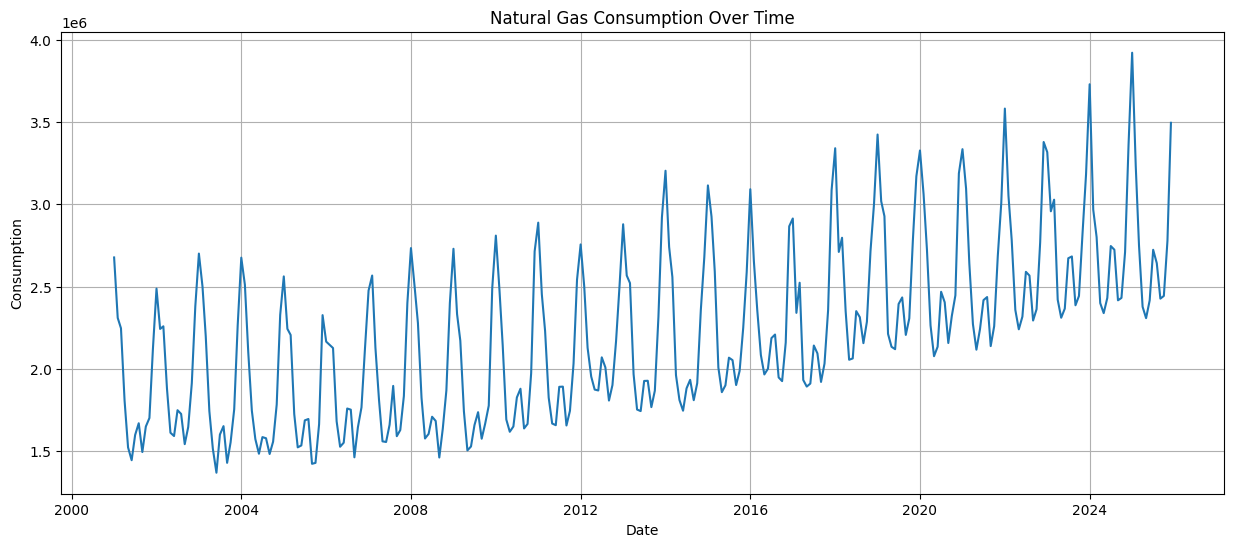

In [7]:
plt.figure(figsize=(15,6))
plt.plot(full_df.index, full_df['consump'])
plt.title('Natural Gas Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Consumption')
plt.grid(True)
plt.show()

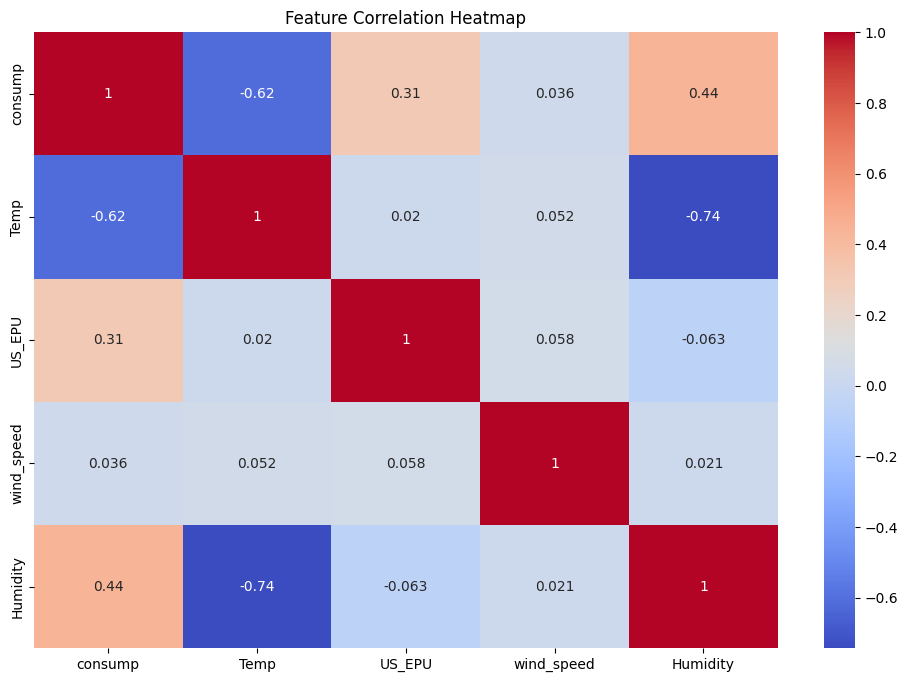

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(full_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [9]:
train_df = full_df[full_df.index.year <= 2024]
test_df = full_df[full_df.index.year == 2025]

# TIMESFM 

In [10]:
consump_series = train_df['consump'].values.astype(np.float32)

In [11]:
# ================================
# Load TimesFM 2.5 Model
# ================================

import timesfm
import numpy as np

model_tf = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tf.compile(
    timesfm.ForecastConfig(
        max_context=256,
        max_horizon=12,
        normalize_inputs=True
    )
)

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

In [12]:
consump_series = train_df["consump"].astype(float).values

context = consump_series[-min(256, len(consump_series)):]

In [13]:
pred, _ = model_tf.forecast(
    horizon=12,
    inputs=[context]
)

timesfm_consumption = np.array(pred[0])

timesfm_consumption

array([3574584.5, 3212554.2, 2959550.5, 2503676.5, 2354450.5, 2436325.2,
       2671405. , 2650055. , 2416394.5, 2488797.2, 2821155. , 3369030.5],
      dtype=float32)

In [14]:
future_dates = pd.date_range(
    start="2025-01-01",
    periods=12,
    freq="MS"
)

In [15]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": timesfm_consumption
})

forecast_df

,Date,Forecast
0,2025-01-01,3574584.50
1,2025-02-01,3212554.25
2,2025-03-01,2959550.50
3,2025-04-01,2503676.50
4,2025-05-01,2354450.50
5,2025-06-01,2436325.25
6,2025-07-01,2671405.00
7,2025-08-01,2650055.00
8,2025-09-01,2416394.50
9,2025-10-01,2488797.25


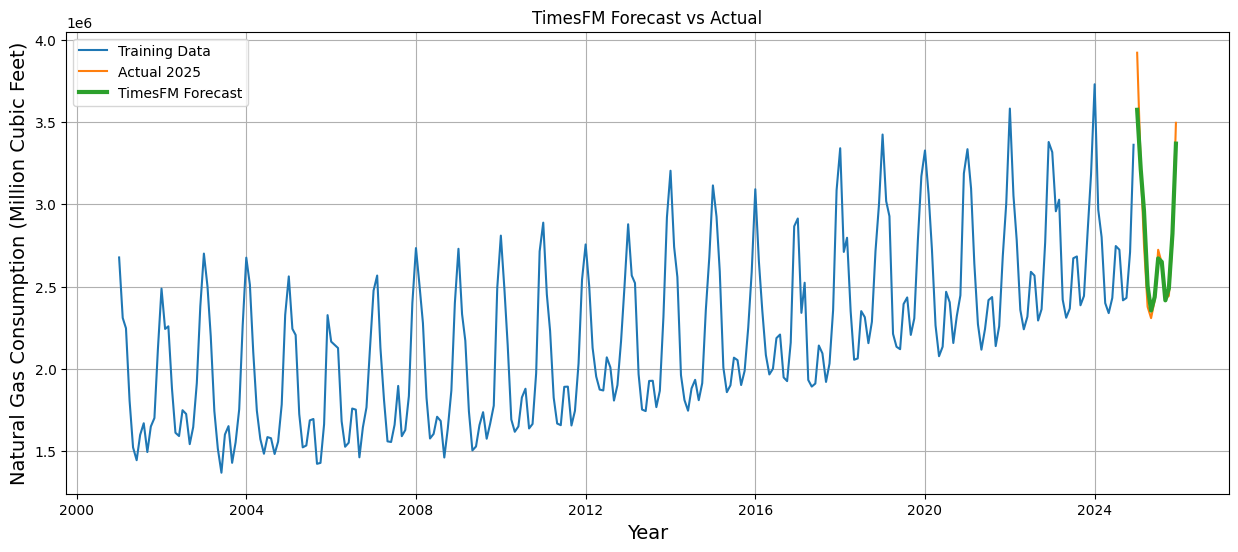

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    train_df.index,
    train_df["consump"],
    label="Training Data"
)

plt.plot(
    test_df.index,
    test_df["consump"],
    label="Actual 2025"
)

plt.plot(
    future_dates,
    timesfm_consumption,
    label="TimesFM Forecast",
    linewidth=3
)

plt.legend()
plt.grid(True)
plt.title("TimesFM Forecast vs Actual")

plt.xlabel("Year", fontsize=14)

plt.ylabel(
    "Natural Gas Consumption (Million Cubic Feet)",
    fontsize=14
)

plt.show()

In [17]:
train_df = full_df[full_df.index.year <= 2025]

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

actual = test_df["consump"].values[:12]
predicted = timesfm_consumption[:12]

mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(actual, predicted)
r2 = r2_score(actual, predicted)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAPE :", mape)
print("R2   :", r2)

MAE  : 87807.7734375
MSE  : 17145875456.0
RMSE : 130942.26000798978
MAPE : 0.029063120484352112
R2   : 0.9264242053031921


In [19]:
residuals = actual - predicted

residuals

array([ 346987.5 ,   19777.75, -208795.5 , -126562.5 ,  -46381.5 ,
        -20321.25,   52117.  ,   -7564.  ,   10297.5 ,  -45642.25,
        -42812.  ,  126434.5 ])

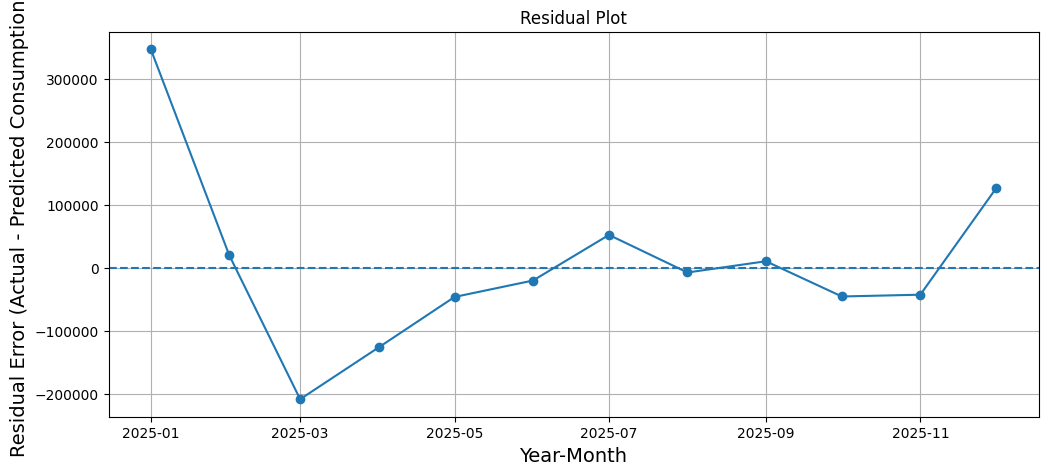

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    future_dates,
    residuals,
    marker='o'
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.xlabel("Year-Month", fontsize=14)

plt.ylabel(
    "Residual Error (Actual - Predicted Consumption)",
    fontsize=14
)
plt.grid(True)

plt.show()

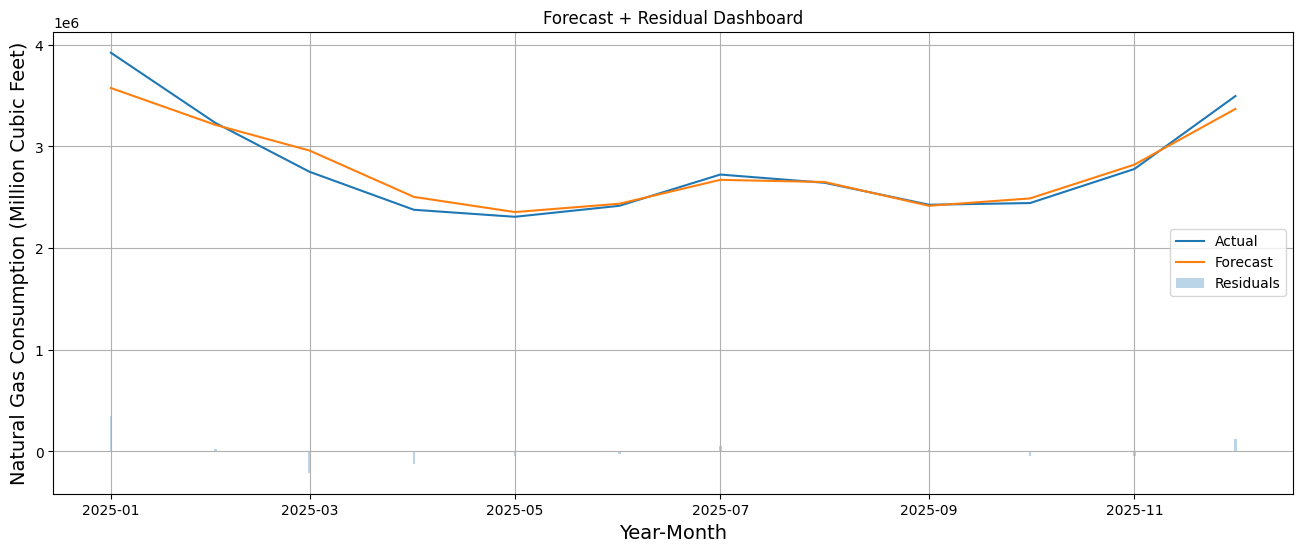

In [21]:
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(
    future_dates,
    actual,
    label="Actual"
)

ax.plot(
    future_dates,
    predicted,
    label="Forecast"
)

ax.bar(
    future_dates,
    residuals,
    alpha=0.3,
    label="Residuals"
)

ax.legend()

plt.title("Forecast + Residual Dashboard")

plt.xlabel("Year-Month", fontsize=14)

plt.ylabel(
    "Natural Gas Consumption (Million Cubic Feet)",
    fontsize=14
)

plt.grid(True)

plt.show()

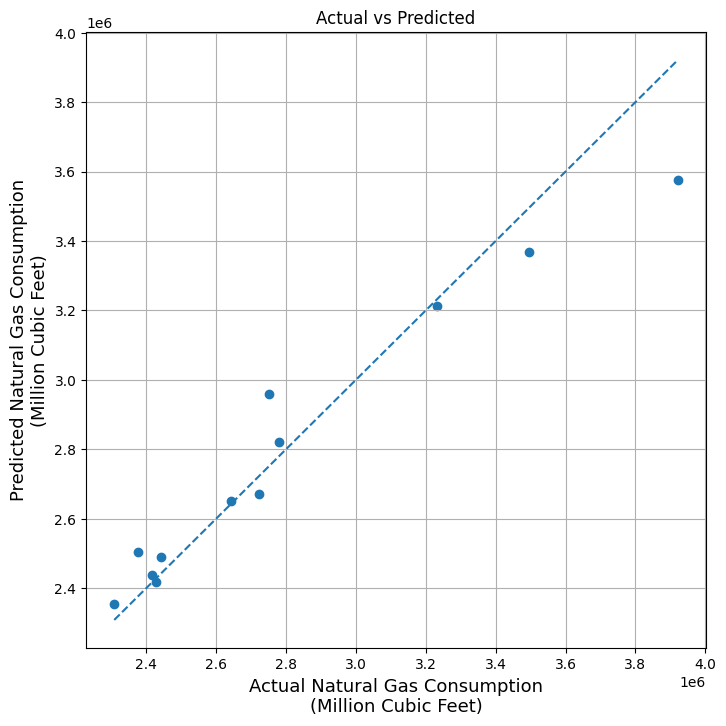

In [22]:
plt.figure(figsize=(8,8))

plt.scatter(actual, predicted)

plt.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    linestyle='--'
)

plt.xlabel(
    "Actual Natural Gas Consumption\n(Million Cubic Feet)",
    fontsize=13
)

plt.ylabel(
    "Predicted Natural Gas Consumption\n(Million Cubic Feet)",
    fontsize=13
)
plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

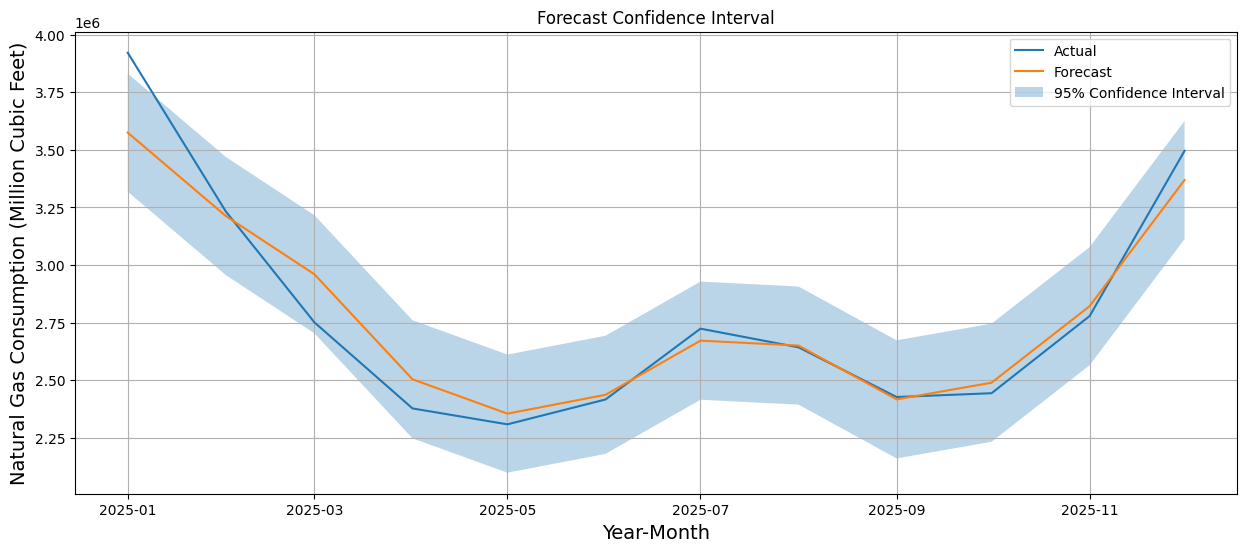

In [23]:
std_error = np.std(residuals)

upper_band = predicted + (1.96 * std_error)
lower_band = predicted - (1.96 * std_error)

plt.figure(figsize=(15,6))

plt.plot(
    future_dates,
    actual,
    label="Actual"
)

plt.plot(
    future_dates,
    predicted,
    label="Forecast"
)

plt.fill_between(
    future_dates,
    lower_band,
    upper_band,
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.legend()

plt.title("Forecast Confidence Interval")

plt.xlabel("Year-Month", fontsize=14)

plt.ylabel(
    "Natural Gas Consumption (Million Cubic Feet)",
    fontsize=14
)

plt.grid(True)

plt.show()

# HYBRID XGBOOST

In [24]:
hybrid_df = full_df.copy()

hybrid_df.head()

,consump,Temp,US_EPU,wind_speed,Humidity
Date,,,,,
2001-01-01,2676998,32.036696,142.614125,1.974750,78.569
2001-02-01,2309464,36.140802,128.625655,1.958117,78.675
2001-03-01,2246633,41.352705,137.374157,1.692071,77.135
2001-04-01,1807170,55.933991,148.758003,2.256230,74.354
2001-05-01,1522382,64.001146,117.436256,1.874177,71.167


In [25]:
# Previous consumption values

for lag in range(1, 13):
    hybrid_df[f'lag_{lag}'] = hybrid_df['consump'].shift(lag)

hybrid_df.head()

,consump,Temp,US_EPU,wind_speed,Humidity,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
Date,,,,,,,,,,,,,,,,,
2001-01-01,2676998,32.036696,142.614125,1.974750,78.569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-02-01,2309464,36.140802,128.625655,1.958117,78.675,2676998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-03-01,2246633,41.352705,137.374157,1.692071,77.135,2309464.0,2676998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-04-01,1807170,55.933991,148.758003,2.256230,74.354,2246633.0,2309464.0,2676998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-05-01,1522382,64.001146,117.436256,1.874177,71.167,1807170.0,2246633.0,2309464.0,2676998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
hybrid_df['rolling_mean_3'] = hybrid_df['consump'].rolling(3).mean()
hybrid_df['rolling_mean_6'] = hybrid_df['consump'].rolling(6).mean()

hybrid_df['rolling_std_3'] = hybrid_df['consump'].rolling(3).std()
hybrid_df['rolling_std_6'] = hybrid_df['consump'].rolling(6).std()

hybrid_df.head()

,consump,Temp,US_EPU,wind_speed,Humidity,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3,rolling_std_6
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,2676998,32.036696,142.614125,1.974750,78.569,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-02-01,2309464,36.140802,128.625655,1.958117,78.675,2676998.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-03-01,2246633,41.352705,137.374157,1.692071,77.135,2309464.0,2676998.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.411032e+06,NaN,232466.129770,NaN
2001-04-01,1807170,55.933991,148.758003,2.256230,74.354,2246633.0,2309464.0,2676998.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.121089e+06,NaN,273670.947601,NaN
2001-05-01,1522382,64.001146,117.436256,1.874177,71.167,1807170.0,2246633.0,2309464.0,2676998.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.858728e+06,NaN,364867.885751,NaN


In [27]:
hybrid_df['month'] = hybrid_df.index.month
hybrid_df['year'] = hybrid_df.index.year
hybrid_df['quarter'] = hybrid_df.index.quarter

hybrid_df.head()

,consump,Temp,US_EPU,wind_speed,Humidity,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_10,lag_11,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3,rolling_std_6,month,year,quarter
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,2676998,32.036696,142.614125,1.974750,78.569,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2001,1
2001-02-01,2309464,36.140802,128.625655,1.958117,78.675,2676998.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2001,1
2001-03-01,2246633,41.352705,137.374157,1.692071,77.135,2309464.0,2676998.0,NaN,NaN,NaN,...,NaN,NaN,NaN,2.411032e+06,NaN,232466.129770,NaN,3,2001,1
2001-04-01,1807170,55.933991,148.758003,2.256230,74.354,2246633.0,2309464.0,2676998.0,NaN,NaN,...,NaN,NaN,NaN,2.121089e+06,NaN,273670.947601,NaN,4,2001,2
2001-05-01,1522382,64.001146,117.436256,1.874177,71.167,1807170.0,2246633.0,2309464.0,2676998.0,NaN,...,NaN,NaN,NaN,1.858728e+06,NaN,364867.885751,NaN,5,2001,2


In [28]:
hybrid_df = hybrid_df.dropna()

hybrid_df.shape

(288, 24)

In [29]:
train_hybrid = hybrid_df[hybrid_df.index.year <= 2024]

test_hybrid = hybrid_df[hybrid_df.index.year == 2025]

In [30]:
FEATURES = [
    'Temp',
    'US_EPU',
    'wind_speed',
    'Humidity',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_5',
    'lag_6',
    'lag_7',
    'lag_8',
    'lag_9',
    'lag_10',
    'lag_11',
    'lag_12',

    'rolling_mean_3',
    'rolling_mean_6',

    'rolling_std_3',
    'rolling_std_6',

    'month',
    'year',
    'quarter'
]

TARGET = 'consump'

In [31]:
X_train = train_hybrid[FEATURES]
y_train = train_hybrid[TARGET]

X_test = test_hybrid[FEATURES]
y_test = test_hybrid[TARGET]

print(X_train.shape)
print(X_test.shape)

(276, 23)
(12, 23)


# TRAIN XGBOOST MODEL

In [32]:
from xgboost import XGBRegressor

hybrid_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

hybrid_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
hybrid_pred = hybrid_model.predict(X_test)

hybrid_pred

array([3583198.2, 3017920. , 2757351.8, 2387559. , 2374697.2, 2444615.8,
       2662563.5, 2699773. , 2437594.5, 2440204.8, 2674775.8, 3364757.5],
      dtype=float32)

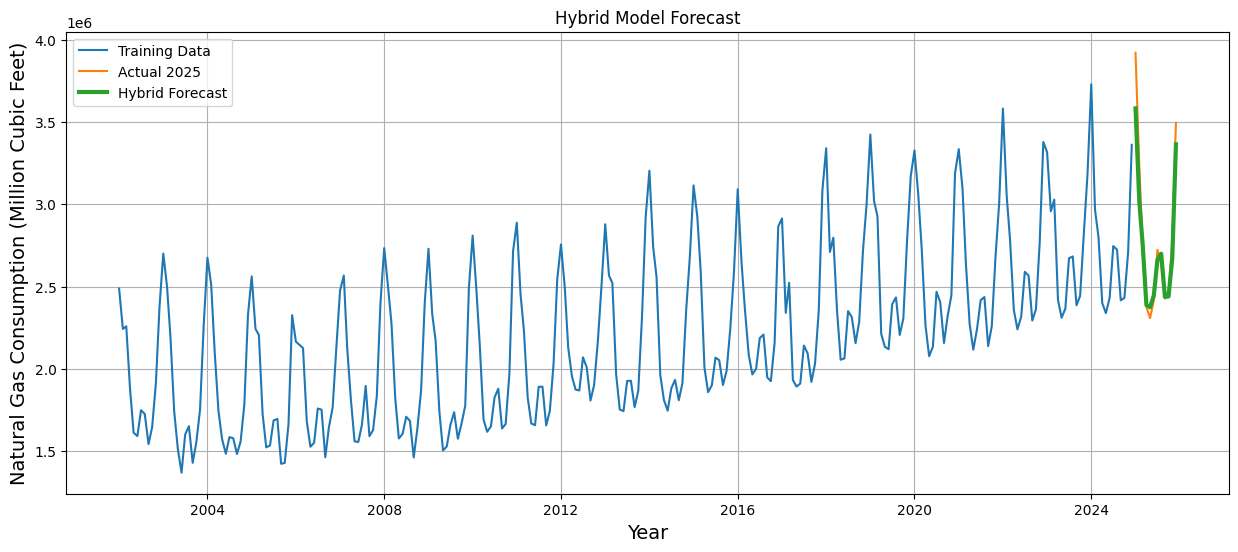

In [34]:
plt.figure(figsize=(15,6))

plt.plot(
    train_hybrid.index,
    train_hybrid['consump'],
    label='Training Data'
)

plt.plot(
    test_hybrid.index,
    y_test,
    label='Actual 2025'
)

plt.plot(
    test_hybrid.index,
    hybrid_pred,
    label='Hybrid Forecast',
    linewidth=3
)

plt.legend()

plt.title("Hybrid Model Forecast")

plt.xlabel("Year", fontsize=14)

plt.ylabel(
    "Natural Gas Consumption (Million Cubic Feet)",
    fontsize=14
)

plt.grid(True)

plt.show()

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

hybrid_mae = mean_absolute_error(y_test, hybrid_pred)

hybrid_rmse = np.sqrt(
    mean_squared_error(y_test, hybrid_pred)
)

hybrid_mape = mean_absolute_percentage_error(
    y_test,
    hybrid_pred
)

hybrid_r2 = r2_score(y_test, hybrid_pred)

print("MAE :", hybrid_mae)
print("RMSE:", hybrid_rmse)
print("MAPE:", hybrid_mape)
print("R2  :", hybrid_r2)

MAE : 85952.9609375
RMSE: 129362.29064143848
MAPE: 0.02704591117799282
R2  : 0.9281890392303467


In [36]:
hybrid_residuals = y_test.values - hybrid_pred

hybrid_residuals

array([338373.75, 214412.  ,  -6596.75, -10445.  , -66628.25, -28611.75,
        60958.5 , -57282.  , -10902.5 ,   2950.25, 103567.25, 130707.5 ])

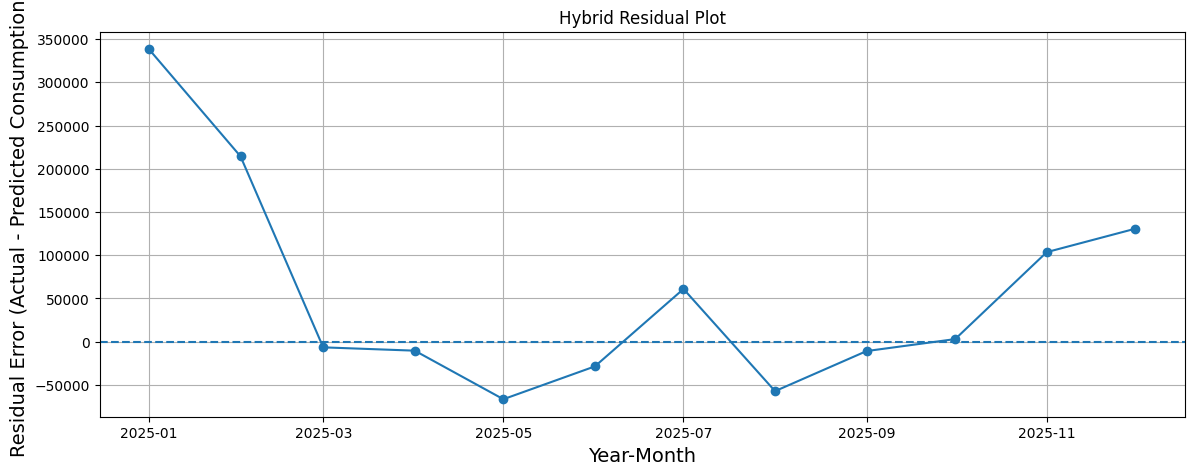

In [37]:
plt.figure(figsize=(14,5))

plt.plot(
    test_hybrid.index,
    hybrid_residuals,
    marker='o'
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Hybrid Residual Plot")

plt.xlabel("Year-Month", fontsize=14)

plt.ylabel(
    "Residual Error (Actual - Predicted Consumption)",
    fontsize=14
)

plt.grid(True)

plt.show()

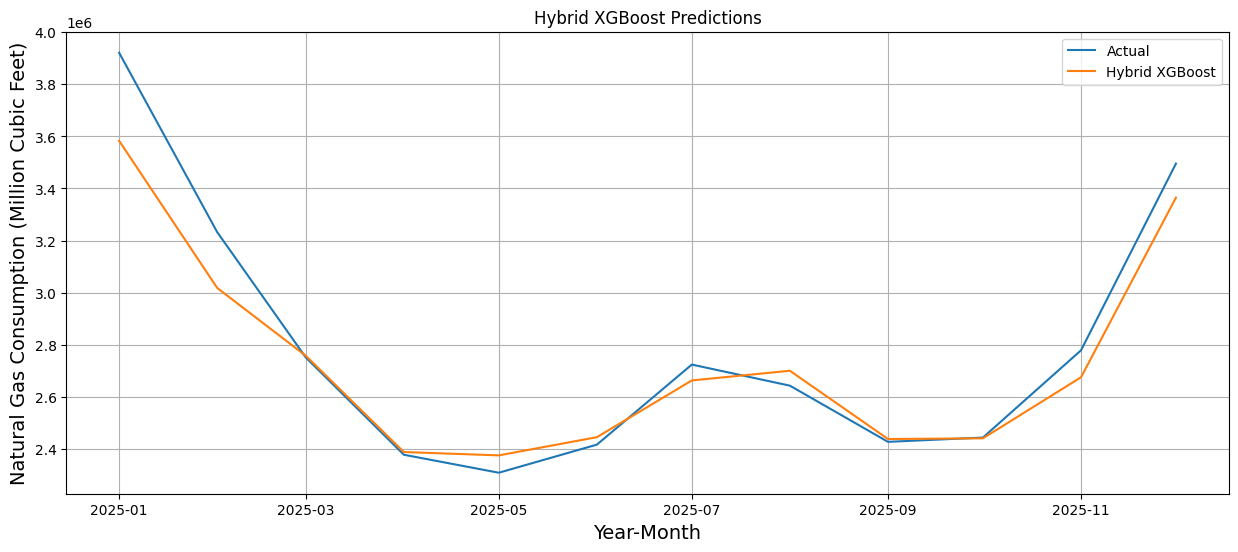

In [38]:
plt.figure(figsize=(15,6))

plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, hybrid_pred, label='Hybrid XGBoost')

plt.legend()
plt.grid(True)
plt.title('Hybrid XGBoost Predictions')
plt.xlabel("Year-Month", fontsize=14)

plt.ylabel(
    "Natural Gas Consumption (Million Cubic Feet)",
    fontsize=14
)
plt.show()

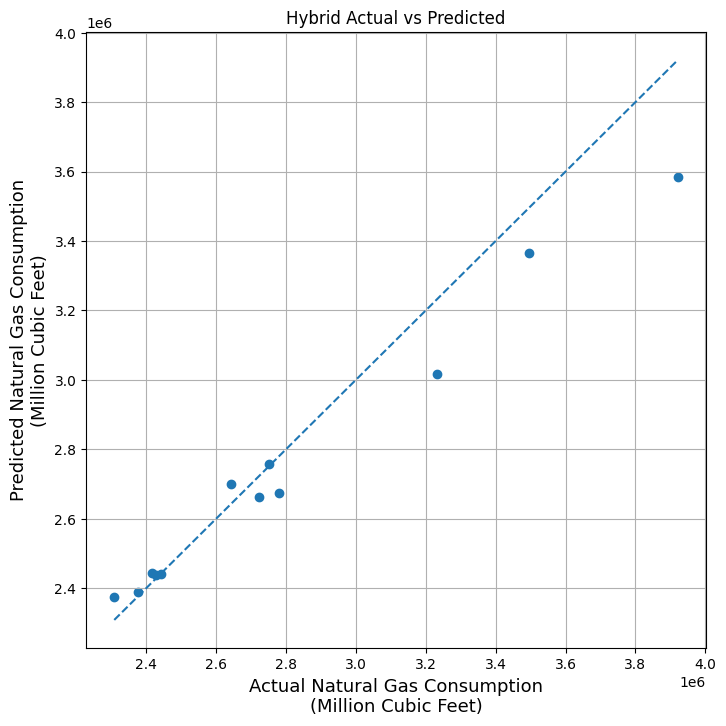

In [39]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    hybrid_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel(
    "Actual Natural Gas Consumption\n(Million Cubic Feet)",
    fontsize=13
)

plt.ylabel(
    "Predicted Natural Gas Consumption\n(Million Cubic Feet)",
    fontsize=13
)

plt.title("Hybrid Actual vs Predicted")

plt.grid(True)

plt.show()

In [40]:
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': hybrid_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
15,lag_12,0.785389
16,rolling_mean_3,0.072865
21,year,0.048476
14,lag_11,0.012089
13,lag_10,0.010616
20,month,0.008940
18,rolling_std_3,0.008533
0,Temp,0.007252
17,rolling_mean_6,0.006791
5,lag_2,0.005779


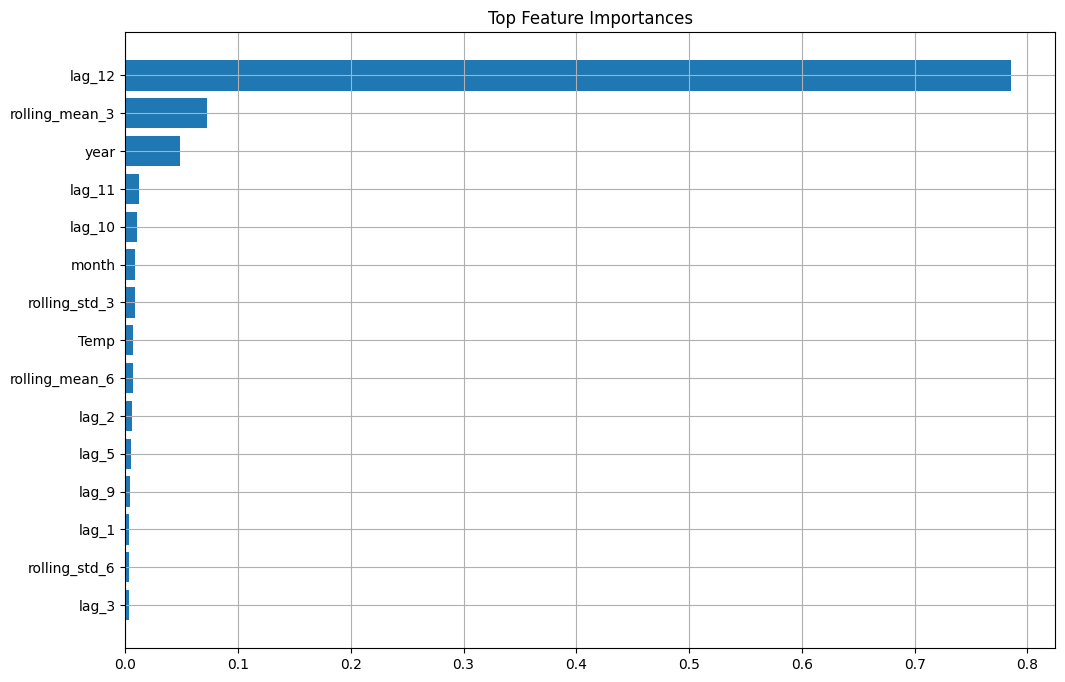

In [41]:
plt.figure(figsize=(12,8))

plt.barh(
    importance_df['Feature'][:15],
    importance_df['Importance'][:15]
)

plt.title("Top Feature Importances")

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

In [42]:
comparison_df = pd.DataFrame({
    'Date': test_hybrid.index,
    'Actual': y_test.values,
    'TimesFM': timesfm_consumption[:len(y_test)],
    'Hybrid': hybrid_pred
})

comparison_df.head()

,Date,Actual,TimesFM,Hybrid
0,2025-01-01,3921572,3574584.50,3583198.25
1,2025-02-01,3232332,3212554.25,3017920.00
2,2025-03-01,2750755,2959550.50,2757351.75
3,2025-04-01,2377114,2503676.50,2387559.00
4,2025-05-01,2308069,2354450.50,2374697.25


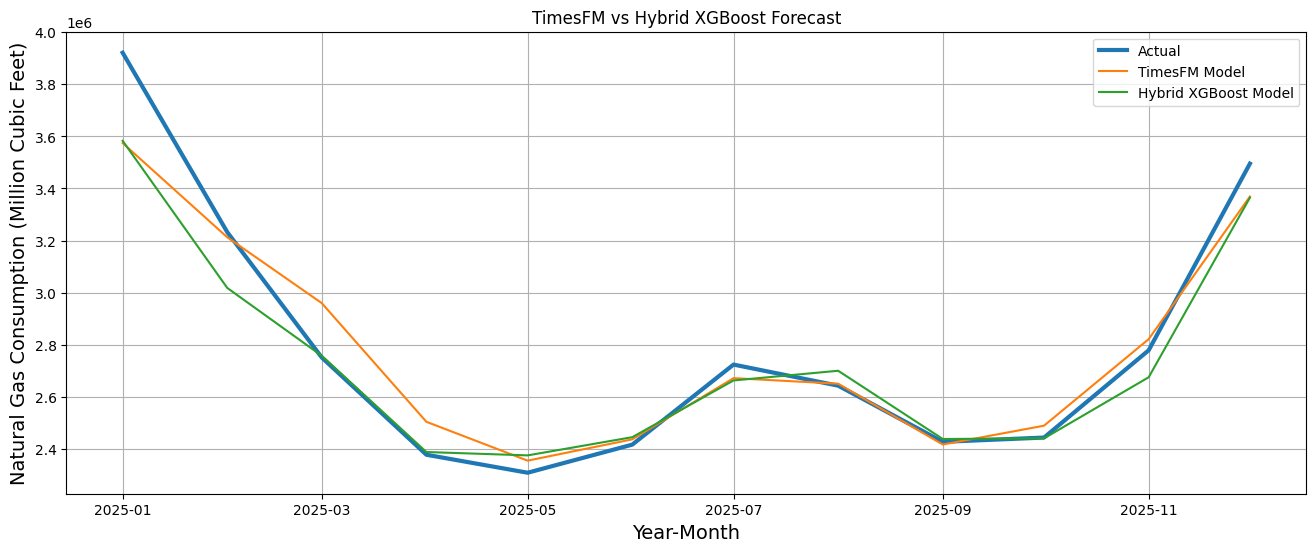

In [43]:
plt.figure(figsize=(16,6))

plt.plot(
    test_hybrid.index,
    y_test.values,
    label='Actual',
    linewidth=3
)

plt.plot(
    test_hybrid.index,
    timesfm_consumption[:len(y_test)],
    label='TimesFM Model'
)

plt.plot(
    test_hybrid.index,
    hybrid_pred,
    label='Hybrid XGBoost Model'
)

plt.legend()

plt.title("TimesFM vs Hybrid XGBoost Forecast")

plt.xlabel("Year-Month", fontsize=14)

plt.ylabel(
    "Natural Gas Consumption (Million Cubic Feet)",
    fontsize=14
)

plt.grid(True)

plt.show()

In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# =========================
# TimesFM Metrics
# =========================

timesfm_mae = mean_absolute_error(
    y_test.values,
    timesfm_consumption[:len(y_test)]
)

timesfm_rmse = np.sqrt(
    mean_squared_error(
        y_test.values,
        timesfm_consumption[:len(y_test)]
    )
)

timesfm_mape = mean_absolute_percentage_error(
    y_test.values,
    timesfm_consumption[:len(y_test)]
)

timesfm_r2 = r2_score(
    y_test.values,
    timesfm_consumption[:len(y_test)]
)

# =========================
# Hybrid Metrics
# =========================

hybrid_mae = mean_absolute_error(
    y_test.values,
    hybrid_pred
)

hybrid_rmse = np.sqrt(
    mean_squared_error(
        y_test.values,
        hybrid_pred
    )
)

hybrid_mape = mean_absolute_percentage_error(
    y_test.values,
    hybrid_pred
)

hybrid_r2 = r2_score(
    y_test.values,
    hybrid_pred
)

# =========================
# Metrics DataFrame
# =========================

metrics_df = pd.DataFrame({
    'Model': ['TimesFM', 'Hybrid XGBoost'],
    'MAE': [timesfm_mae, hybrid_mae],
    'RMSE': [timesfm_rmse, hybrid_rmse],
    'MAPE': [timesfm_mape, hybrid_mape],
    'R2': [timesfm_r2, hybrid_r2]
})

metrics_df

,Model,MAE,RMSE,MAPE,R2
0,TimesFM,87807.773438,130942.260008,0.029063,0.926424
1,Hybrid XGBoost,85952.960938,129362.290641,0.027046,0.928189


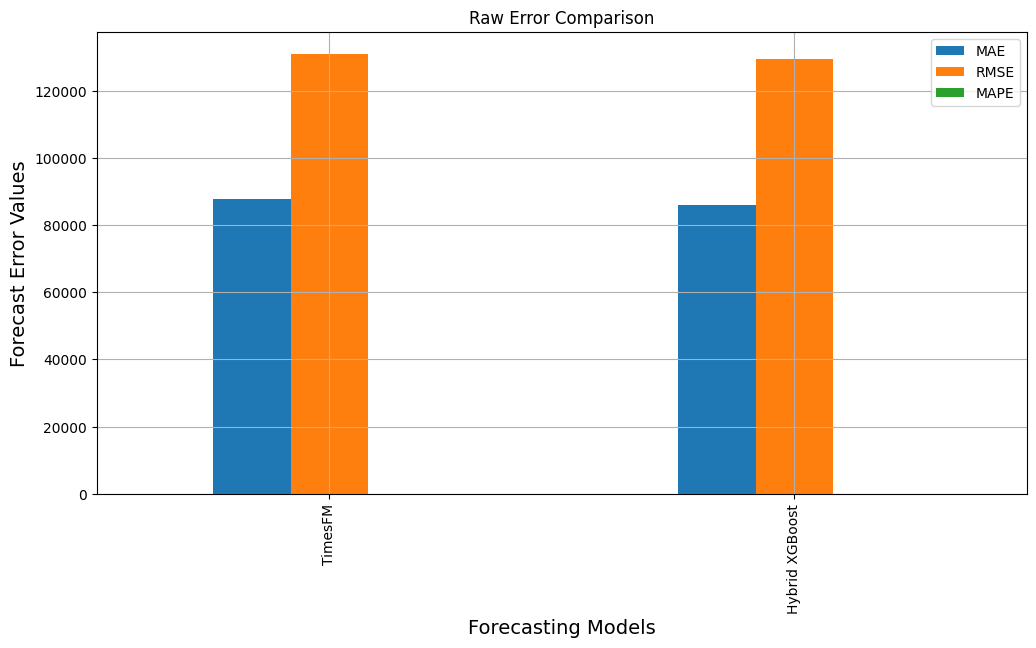

In [45]:
metrics_df.set_index('Model')[['MAE', 'RMSE', 'MAPE']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Raw Error Comparison")

plt.xlabel("Forecasting Models", fontsize=14)

plt.ylabel(
    "Forecast Error Values",
    fontsize=14
)
plt.grid(True)

plt.show()

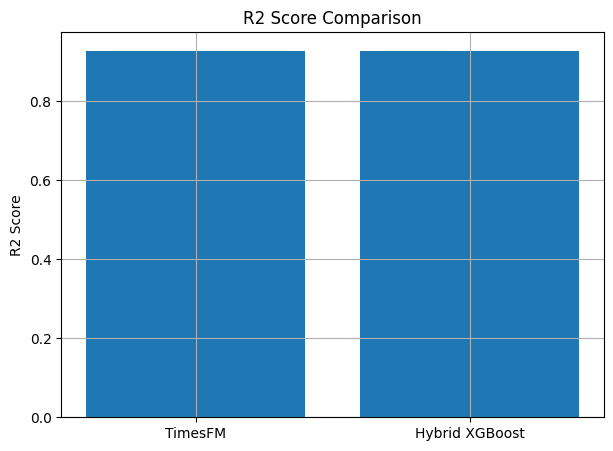

In [46]:
plt.figure(figsize=(7,5))

plt.bar(
    metrics_df['Model'],
    metrics_df['R2']
)

plt.title("R2 Score Comparison")

plt.ylabel("R2 Score")

plt.grid(True)

plt.show()

In [47]:
!pip install shap -q
import shap

In [48]:
explainer = shap.Explainer(
    hybrid_model,
    X_train
)

In [49]:
shap_values = explainer(X_test)

shap_values

.values =
array([[ 2.21681011e+05, -2.65045486e+03, -1.44459389e+03,
        -6.32871950e+03,  1.01072108e+04,  4.81003974e+03,
         5.55242313e+03,  8.80903750e+03,  1.77987481e+04,
         8.85147562e+03,  1.76713508e+03,  1.95959885e+03,
         3.88631840e+03,  8.51678539e+04,  2.40168161e+04,
         6.29813319e+05,  2.45917689e+05,  1.05591038e+04,
         6.49141941e+04,  3.01159875e+03,  2.62735495e+03,
         3.01903609e+04,  0.00000000e+00],
       [ 1.06883633e+05, -1.92061664e+03, -1.70370264e+02,
         1.00080319e+04,  3.72814437e+03, -1.87964495e+04,
         2.80604891e+03,  4.48277182e+03,  5.95493833e+03,
        -5.85750920e+03, -3.48836852e+03,  4.62740087e+03,
         2.98429259e+03,  3.35059449e+03,  1.97415646e+04,
         4.49103217e+05,  1.78936567e+05,  1.45029932e+04,
        -7.03525892e+03,  2.45877170e+03, -2.55618038e+02,
         3.36940411e+04,  0.00000000e+00],
       [-4.95512634e+04, -1.51061646e+04,  2.56697973e+03,
         4.01505696

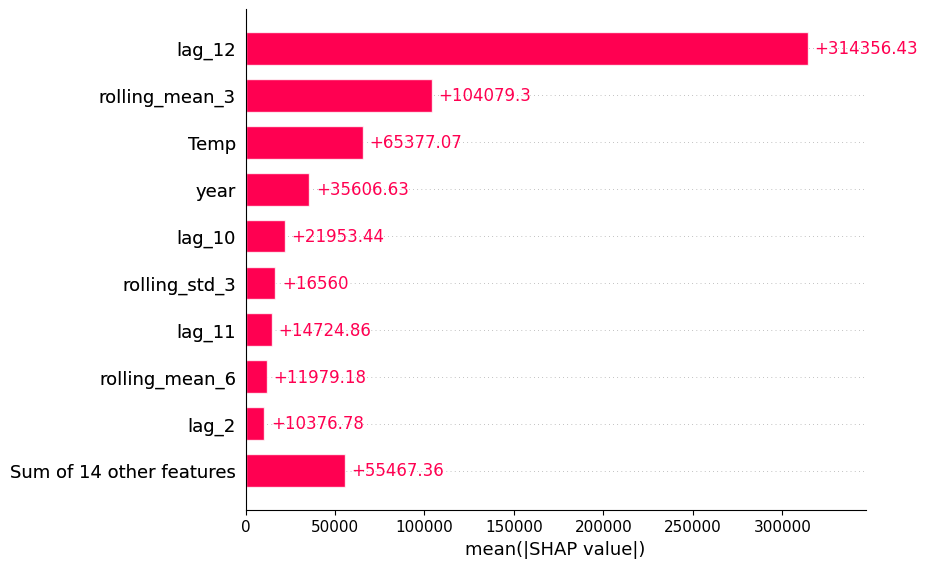

In [50]:
shap.plots.bar(shap_values)


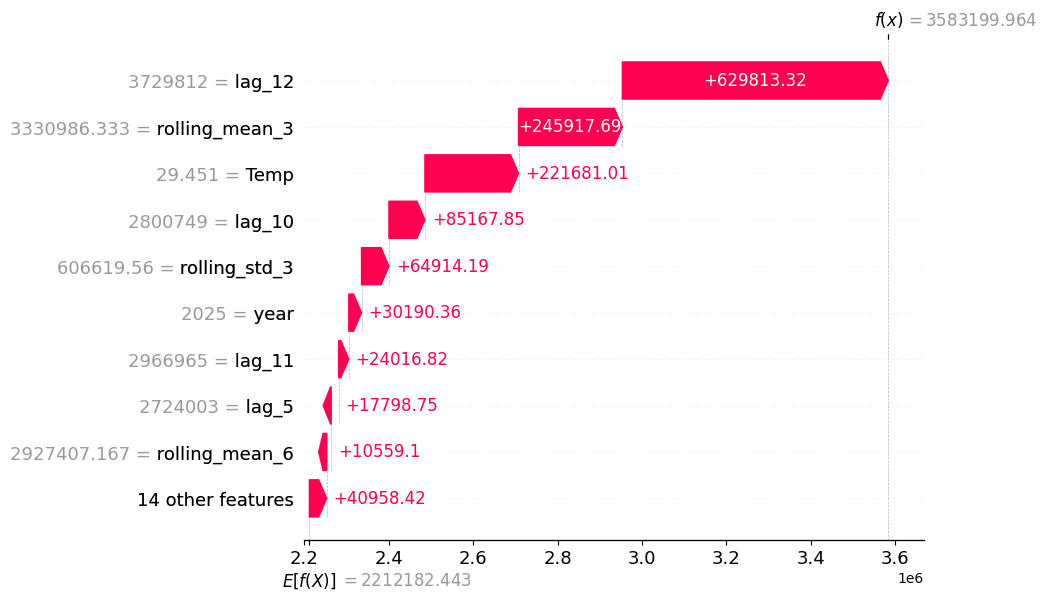

In [51]:
shap.plots.waterfall(
    shap_values[0]
)

In [52]:
shap.initjs()

shap.plots.force(
    shap_values[0]
)

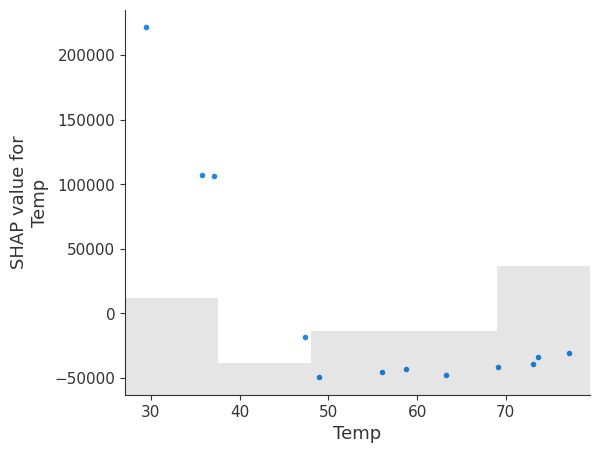

In [53]:
shap.plots.scatter(
    shap_values[:, "Temp"]
)

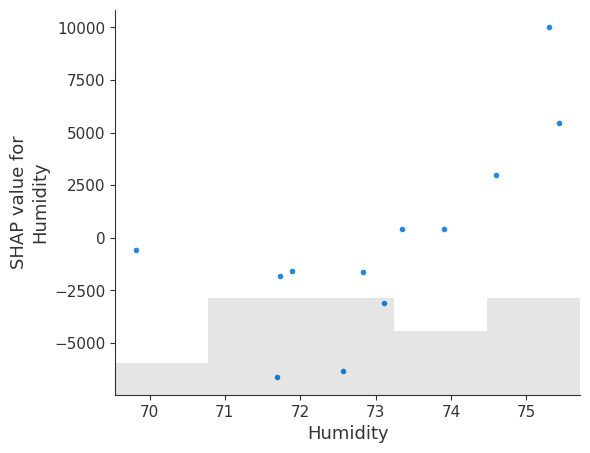

In [54]:
shap.plots.scatter(
    shap_values[:, "Humidity"]
)


In [55]:
shap_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': np.abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by='Importance',
    ascending=False
)

shap_importance

,Feature,Importance
15,lag_12,314356.432697
16,rolling_mean_3,104079.295774
0,Temp,65377.074040
21,year,35606.634383
13,lag_10,21953.442927
18,rolling_std_3,16559.995449
14,lag_11,14724.856811
17,rolling_mean_6,11979.178051
5,lag_2,10376.780863
4,lag_1,9529.802011


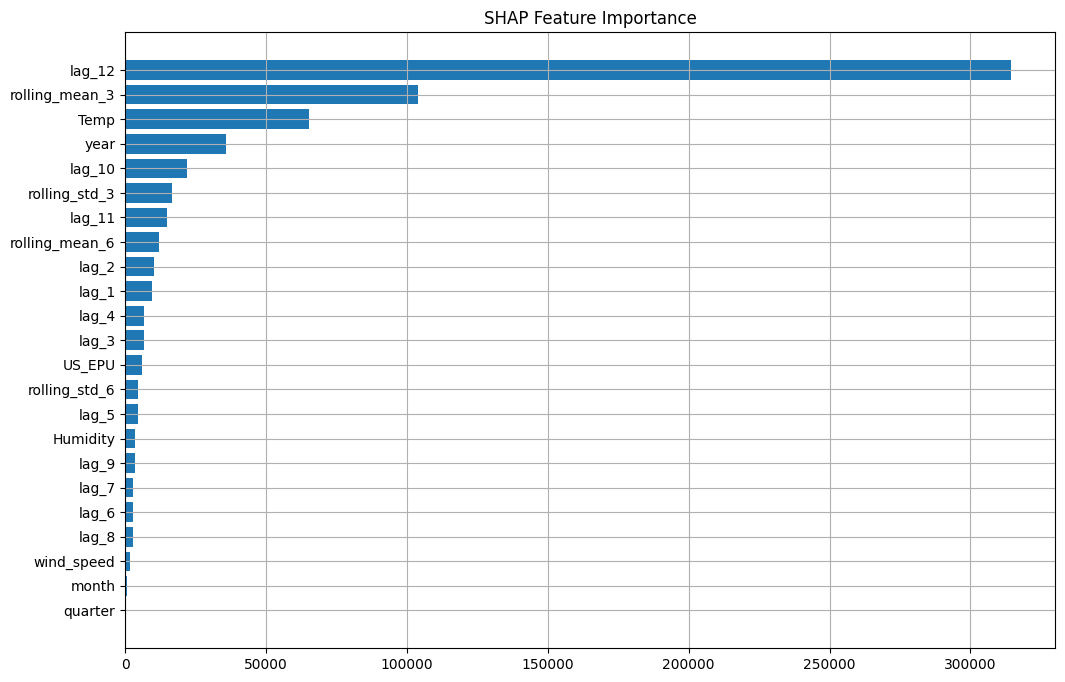

In [56]:
plt.figure(figsize=(12,8))

plt.barh(
    shap_importance['Feature'],
    shap_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("SHAP Feature Importance")

plt.grid(True)

plt.show()

In [57]:
month_index = 5

print("Actual Value:")
print(y_test.values[month_index])

print()

print("Predicted Value:")
print(hybrid_pred[month_index])

Actual Value:
2416004

Predicted Value:
2444615.8


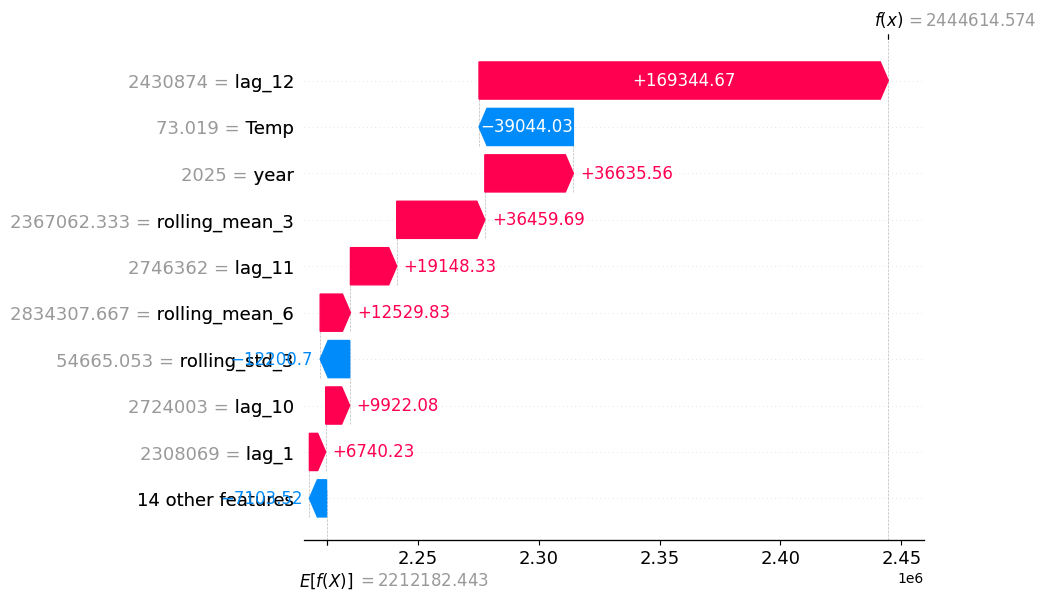

In [58]:
shap.plots.waterfall(
    shap_values[month_index]
)

In [59]:
importance_table = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": np.abs(shap_values.values).mean(axis=0)
})

importance_table = importance_table.sort_values(
    by="Importance",
    ascending=False
)

importance_table



,Feature,Importance
15,lag_12,314356.432697
16,rolling_mean_3,104079.295774
0,Temp,65377.074040
21,year,35606.634383
13,lag_10,21953.442927
18,rolling_std_3,16559.995449
14,lag_11,14724.856811
17,rolling_mean_6,11979.178051
5,lag_2,10376.780863
4,lag_1,9529.802011


In [60]:
top_features = importance_table.head(10)

top_features

for i in range(10):

    feature = top_features.iloc[i]['Feature']
    importance = top_features.iloc[i]['Importance']

    print(
        f"{i+1}. {feature} influences prediction strongly "
        f"(importance score = {importance:.2f})"
    )

1. lag_12 influences prediction strongly (importance score = 314356.43)
2. rolling_mean_3 influences prediction strongly (importance score = 104079.30)
3. Temp influences prediction strongly (importance score = 65377.07)
4. year influences prediction strongly (importance score = 35606.63)
5. lag_10 influences prediction strongly (importance score = 21953.44)
6. rolling_std_3 influences prediction strongly (importance score = 16560.00)
7. lag_11 influences prediction strongly (importance score = 14724.86)
8. rolling_mean_6 influences prediction strongly (importance score = 11979.18)
9. lag_2 influences prediction strongly (importance score = 10376.78)
10. lag_1 influences prediction strongly (importance score = 9529.80)


# FINAL MODEL


In [61]:
# Add TimesFM predictions into hybrid dataframe

hybrid_df['timesfm_pred'] = np.nan

hybrid_df.loc[
    test_hybrid.index,
    'timesfm_pred'
] = timesfm_consumption[:len(test_hybrid)]

In [62]:
hybrid_df['timesfm_pred'] = (
    hybrid_df['timesfm_pred']
    .fillna(hybrid_df['consump'].shift(1))
)

In [63]:
hybrid_df = hybrid_df.dropna()

In [64]:
train_ensemble = hybrid_df[
    hybrid_df.index.year <= 2024
]

test_ensemble = hybrid_df[
    hybrid_df.index.year == 2025
]

In [65]:
ENSEMBLE_FEATURES = FEATURES + ['timesfm_pred']

ENSEMBLE_FEATURES

['Temp',
 'US_EPU',
 'wind_speed',
 'Humidity',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_4',
 'lag_5',
 'lag_6',
 'lag_7',
 'lag_8',
 'lag_9',
 'lag_10',
 'lag_11',
 'lag_12',
 'rolling_mean_3',
 'rolling_mean_6',
 'rolling_std_3',
 'rolling_std_6',
 'month',
 'year',
 'quarter',
 'timesfm_pred']

In [66]:
X_train_ensemble = train_ensemble[
    ENSEMBLE_FEATURES
]

y_train_ensemble = train_ensemble[
    TARGET
]

X_test_ensemble = test_ensemble[
    ENSEMBLE_FEATURES
]

y_test_ensemble = test_ensemble[
    TARGET
]

In [67]:
ensemble_model = XGBRegressor(

    n_estimators=1200,

    learning_rate=0.02,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

ensemble_model.fit(

    X_train_ensemble,

    y_train_ensemble
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1200,
             n_jobs=None, num_parallel_tree=None, ...)

In [68]:
ensemble_pred = ensemble_model.predict(
    X_test_ensemble
)

ensemble_pred

array([3590623.5, 3057063. , 2830505.5, 2437839.5, 2365700.2, 2448304.5,
       2705364.8, 2664824.5, 2451451.8, 2449670. , 2682657.5, 3382312. ],
      dtype=float32)

In [69]:
comparison_all = pd.DataFrame({

    'Date': test_ensemble.index,

    'Actual': y_test_ensemble.values,

    'TimesFM': timesfm_consumption[
        :len(test_ensemble)
    ],

    'Hybrid_XGBoost': hybrid_pred,

    'TimesFM_XGBoost_Ensemble': ensemble_pred
})

comparison_all

,Date,Actual,TimesFM,Hybrid_XGBoost,TimesFM_XGBoost_Ensemble
0,2025-01-01,3921572,3574584.50,3583198.25,3590623.50
1,2025-02-01,3232332,3212554.25,3017920.00,3057063.00
2,2025-03-01,2750755,2959550.50,2757351.75,2830505.50
3,2025-04-01,2377114,2503676.50,2387559.00,2437839.50
4,2025-05-01,2308069,2354450.50,2374697.25,2365700.25
5,2025-06-01,2416004,2436325.25,2444615.75,2448304.50
6,2025-07-01,2723522,2671405.00,2662563.50,2705364.75
7,2025-08-01,2642491,2650055.00,2699773.00,2664824.50
8,2025-09-01,2426692,2416394.50,2437594.50,2451451.75
9,2025-10-01,2443155,2488797.25,2440204.75,2449670.00


In [70]:
# ==========================
# TimesFM
# ==========================

timesfm_mae = mean_absolute_error(

    y_test_ensemble,

    timesfm_consumption[:len(test_ensemble)]
)

timesfm_rmse = np.sqrt(

    mean_squared_error(

        y_test_ensemble,

        timesfm_consumption[:len(test_ensemble)]
    )
)

timesfm_r2 = r2_score(

    y_test_ensemble,

    timesfm_consumption[:len(test_ensemble)]
)

# ==========================
# Hybrid XGBoost
# ==========================

hybrid_mae = mean_absolute_error(

    y_test_ensemble,

    hybrid_pred
)

hybrid_rmse = np.sqrt(

    mean_squared_error(

        y_test_ensemble,

        hybrid_pred
    )
)

hybrid_r2 = r2_score(

    y_test_ensemble,

    hybrid_pred
)

# ==========================
# Ensemble Model
# ==========================

ensemble_mae = mean_absolute_error(

    y_test_ensemble,

    ensemble_pred
)

ensemble_rmse = np.sqrt(

    mean_squared_error(

        y_test_ensemble,

        ensemble_pred
    )
)

ensemble_r2 = r2_score(

    y_test_ensemble,

    ensemble_pred
)

metrics_all = pd.DataFrame({

    'Model': [

        'TimesFM',

        'Hybrid_XGBoost',

        'TimesFM_XGBoost_Ensemble'
    ],

    'MAE': [

        timesfm_mae,

        hybrid_mae,

        ensemble_mae
    ],

    'RMSE': [

        timesfm_rmse,

        hybrid_rmse,

        ensemble_rmse
    ],

    'R2': [

        timesfm_r2,

        hybrid_r2,

        ensemble_r2
    ]
})

metrics_all

,Model,MAE,RMSE,R2
0,TimesFM,87807.773438,130942.260008,0.926424
1,Hybrid_XGBoost,85952.960938,129362.290641,0.928189
2,TimesFM_XGBoost_Ensemble,84769.101562,121827.000751,0.936311


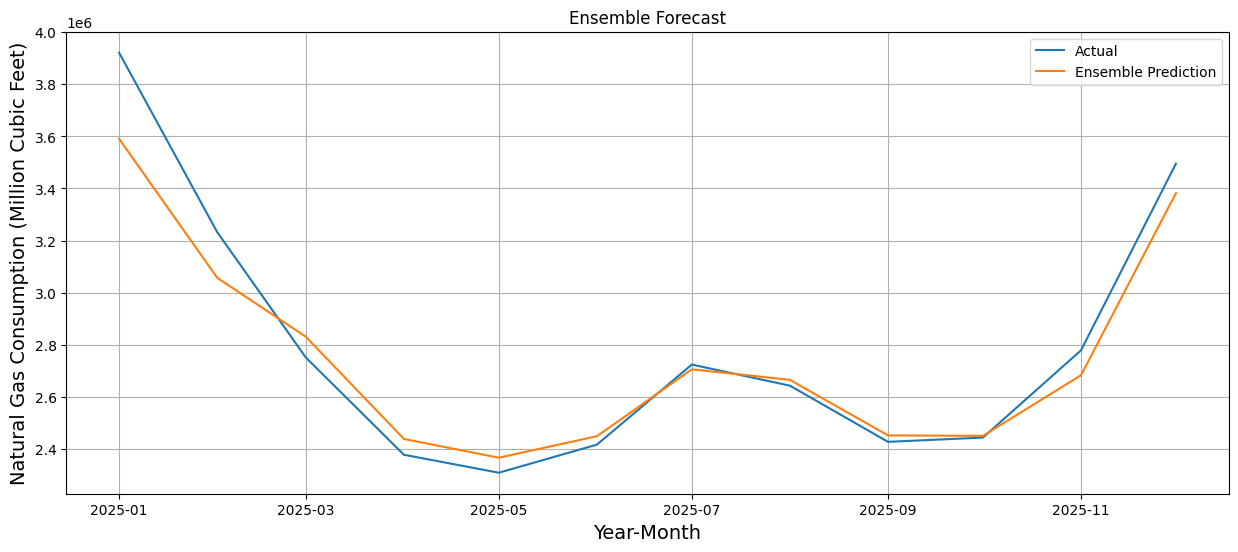

In [71]:
plt.figure(figsize=(15,6))

plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, ensemble_pred, label='Ensemble Prediction')

plt.legend()
plt.grid(True)
plt.title('Ensemble Forecast')
plt.xlabel("Year-Month", fontsize=14)

plt.ylabel(
    "Natural Gas Consumption (Million Cubic Feet)",
    fontsize=14
)

plt.show()

In [72]:
# =============================
# RESIDUAL VALUES — FINAL ENSEMBLE MODEL
# =============================

ensemble_residual_df = pd.DataFrame({
    'Date': y_test.index,
    'Actual': y_test.values,
    'Predicted': ensemble_pred,
    'Residual': y_test.values - ensemble_pred
})

ensemble_residual_df

,Date,Actual,Predicted,Residual
0,2025-01-01,3921572,3590623.50,330948.50
1,2025-02-01,3232332,3057063.00,175269.00
2,2025-03-01,2750755,2830505.50,-79750.50
3,2025-04-01,2377114,2437839.50,-60725.50
4,2025-05-01,2308069,2365700.25,-57631.25
5,2025-06-01,2416004,2448304.50,-32300.50
6,2025-07-01,2723522,2705364.75,18157.25
7,2025-08-01,2642491,2664824.50,-22333.50
8,2025-09-01,2426692,2451451.75,-24759.75
9,2025-10-01,2443155,2449670.00,-6515.00


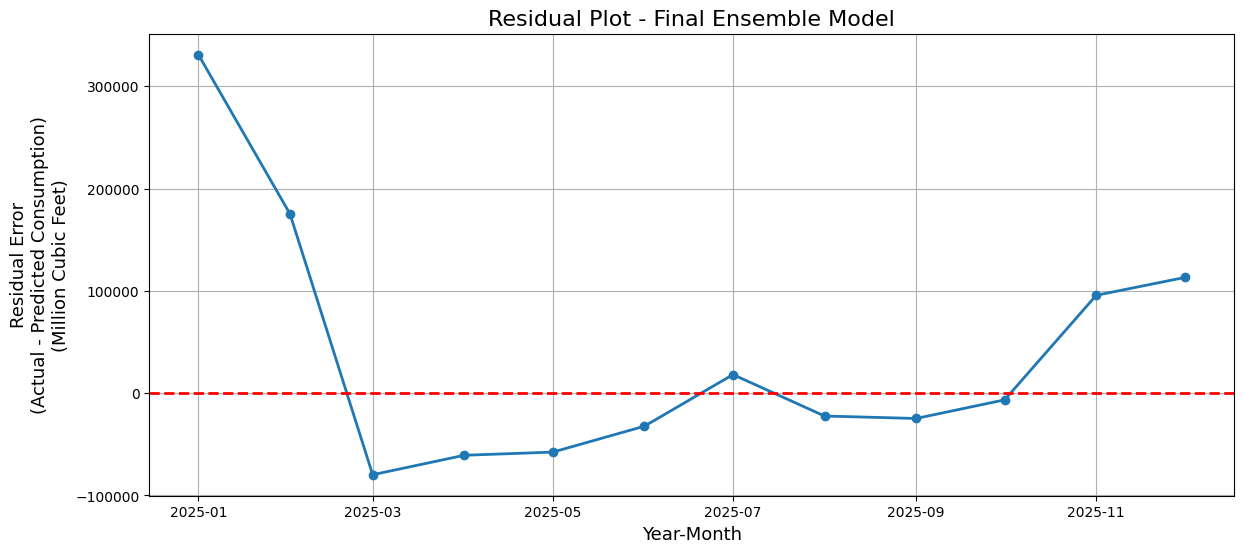

In [73]:
# =============================
# RESIDUAL ANALYSIS — FINAL ENSEMBLE MODEL
# =============================

# Calculate residuals
ensemble_residuals = y_test.values - ensemble_pred

# Residual Plot
plt.figure(figsize=(14,6))

plt.plot(
    y_test.index,
    ensemble_residuals,
    marker='o',
    linewidth=2
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.title('Residual Plot - Final Ensemble Model', fontsize=16)
plt.xlabel("Year-Month", fontsize=13)

plt.ylabel(
    "Residual Error\n(Actual - Predicted Consumption)\n(Million Cubic Feet)",
    fontsize=13
)

plt.grid(True)
plt.show()

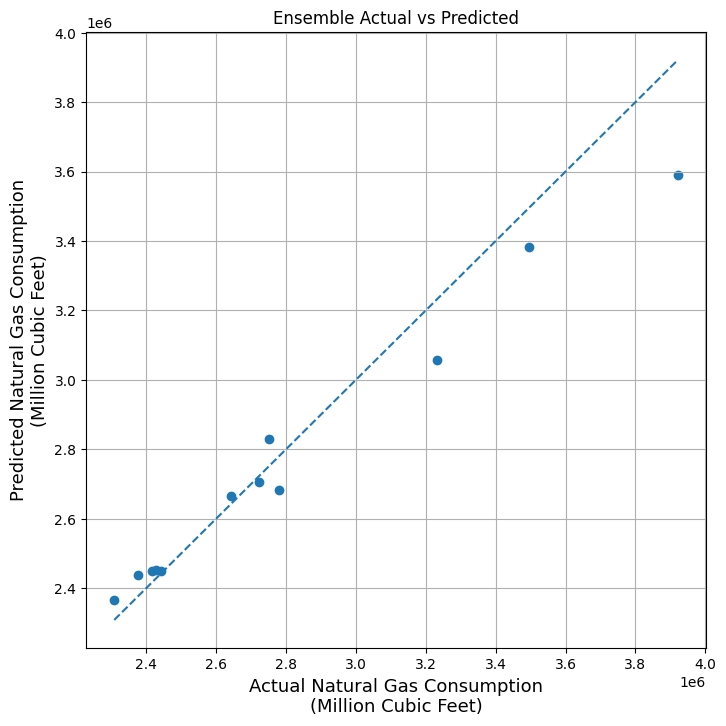

In [74]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    ensemble_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel(
    "Actual Natural Gas Consumption\n(Million Cubic Feet)",
    fontsize=13
)

plt.ylabel(
    "Predicted Natural Gas Consumption\n(Million Cubic Feet)",
    fontsize=13
)

plt.title("Ensemble Actual vs Predicted")

plt.grid(True)

plt.show()

In [75]:
importance_ensemble = pd.DataFrame({

    'Feature': ENSEMBLE_FEATURES,

    'Importance': ensemble_model.feature_importances_
})

importance_ensemble = (
    importance_ensemble
    .sort_values(
        by='Importance',
        ascending=False
    )
)

importance_ensemble.head(20)

,Feature,Importance
15,lag_12,0.527353
16,rolling_mean_3,0.206185
14,lag_11,0.067275
21,year,0.042040
22,quarter,0.039398
4,lag_1,0.023057
0,Temp,0.011036
23,timesfm_pred,0.010775
20,month,0.010753
18,rolling_std_3,0.010734


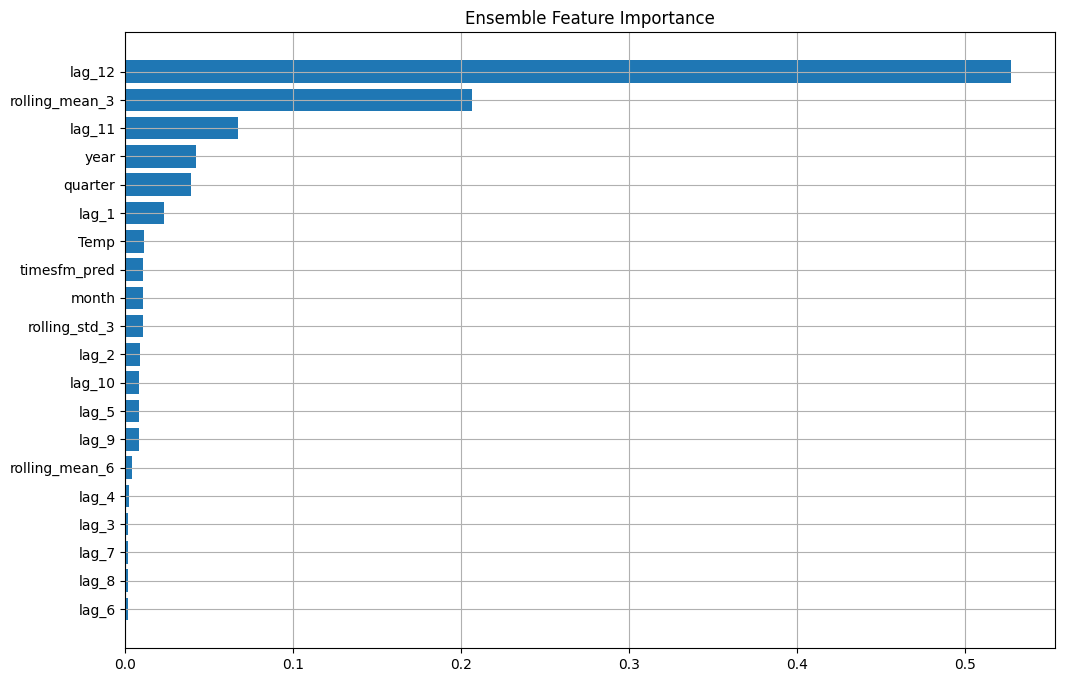

In [76]:
plt.figure(figsize=(12,8))

plt.barh(

    importance_ensemble['Feature'][:20],

    importance_ensemble['Importance'][:20]
)

plt.gca().invert_yaxis()

plt.title(
    "Ensemble Feature Importance"
)

plt.grid(True)

plt.show()

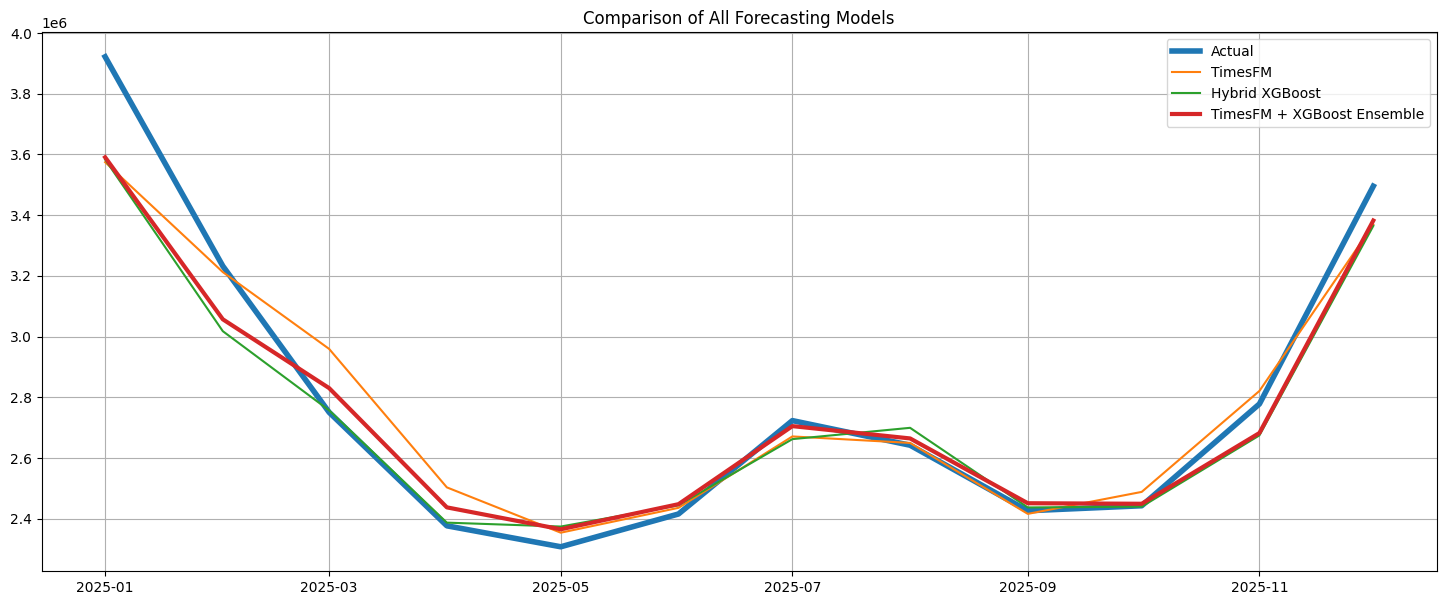

In [77]:
plt.figure(figsize=(18,7))

plt.plot(

    test_ensemble.index,

    y_test_ensemble.values,

    label='Actual',

    linewidth=4
)

plt.plot(

    test_ensemble.index,

    timesfm_consumption[
        :len(test_ensemble)
    ],

    label='TimesFM'
)

plt.plot(

    test_ensemble.index,

    hybrid_pred,

    label='Hybrid XGBoost'
)

plt.plot(

    test_ensemble.index,

    ensemble_pred,

    label='TimesFM + XGBoost Ensemble',

    linewidth=3
)

plt.legend()

plt.title(
    "Comparison of All Forecasting Models"
)

plt.grid(True)

plt.show()

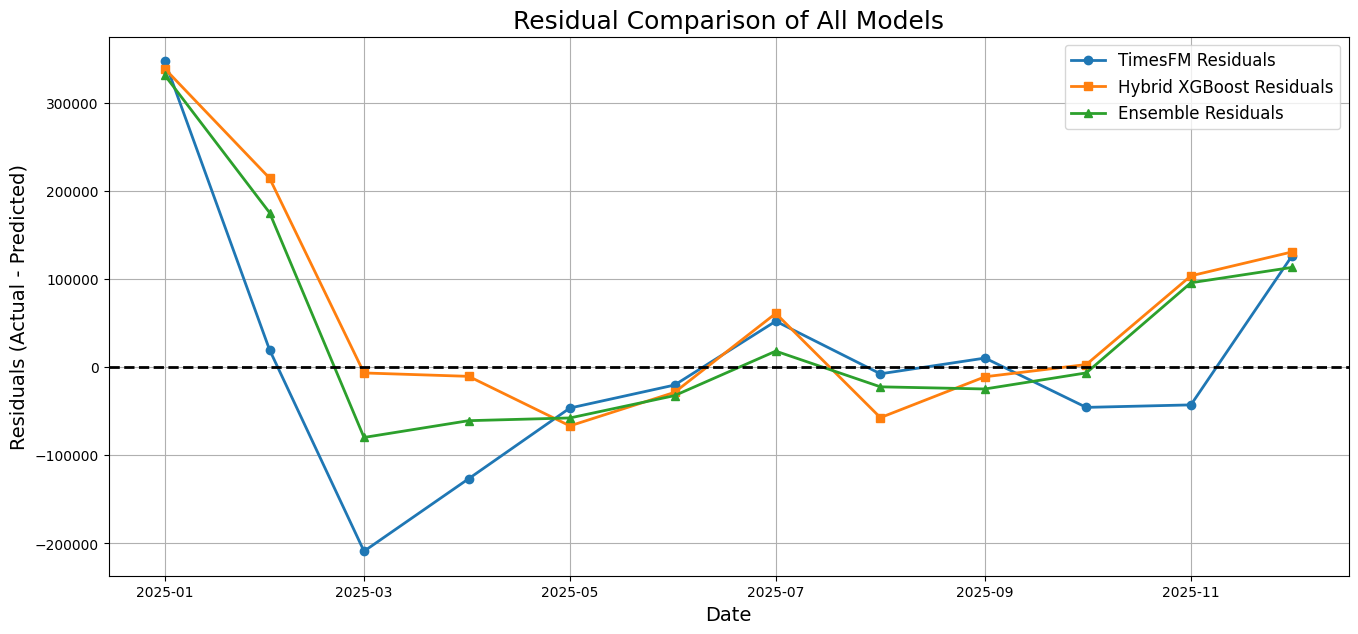

In [78]:
# =============================
# RESIDUAL COMPARISON OF ALL MODELS
# =============================

actual_values = y_test.values

pred_values = timesfm_consumption[:len(y_test)]
# TimesFM Residuals
timesfm_residuals = actual_values - pred_values

# Hybrid XGBoost Residuals
hybrid_residuals = y_test.values - hybrid_pred

# Ensemble Residuals
ensemble_residuals = y_test.values - ensemble_pred

# Plot Comparison
plt.figure(figsize=(16,7))

plt.plot(
    y_test.index,
    timesfm_residuals,
    marker='o',
    linewidth=2,
    label='TimesFM Residuals'
)

plt.plot(
    y_test.index,
    hybrid_residuals,
    marker='s',
    linewidth=2,
    label='Hybrid XGBoost Residuals'
)

plt.plot(
    y_test.index,
    ensemble_residuals,
    marker='^',
    linewidth=2,
    label='Ensemble Residuals'
)

# Zero Error Line
plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=2
)

plt.title('Residual Comparison of All Models', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=14)

plt.legend(fontsize=12)
plt.grid(True)

plt.show()

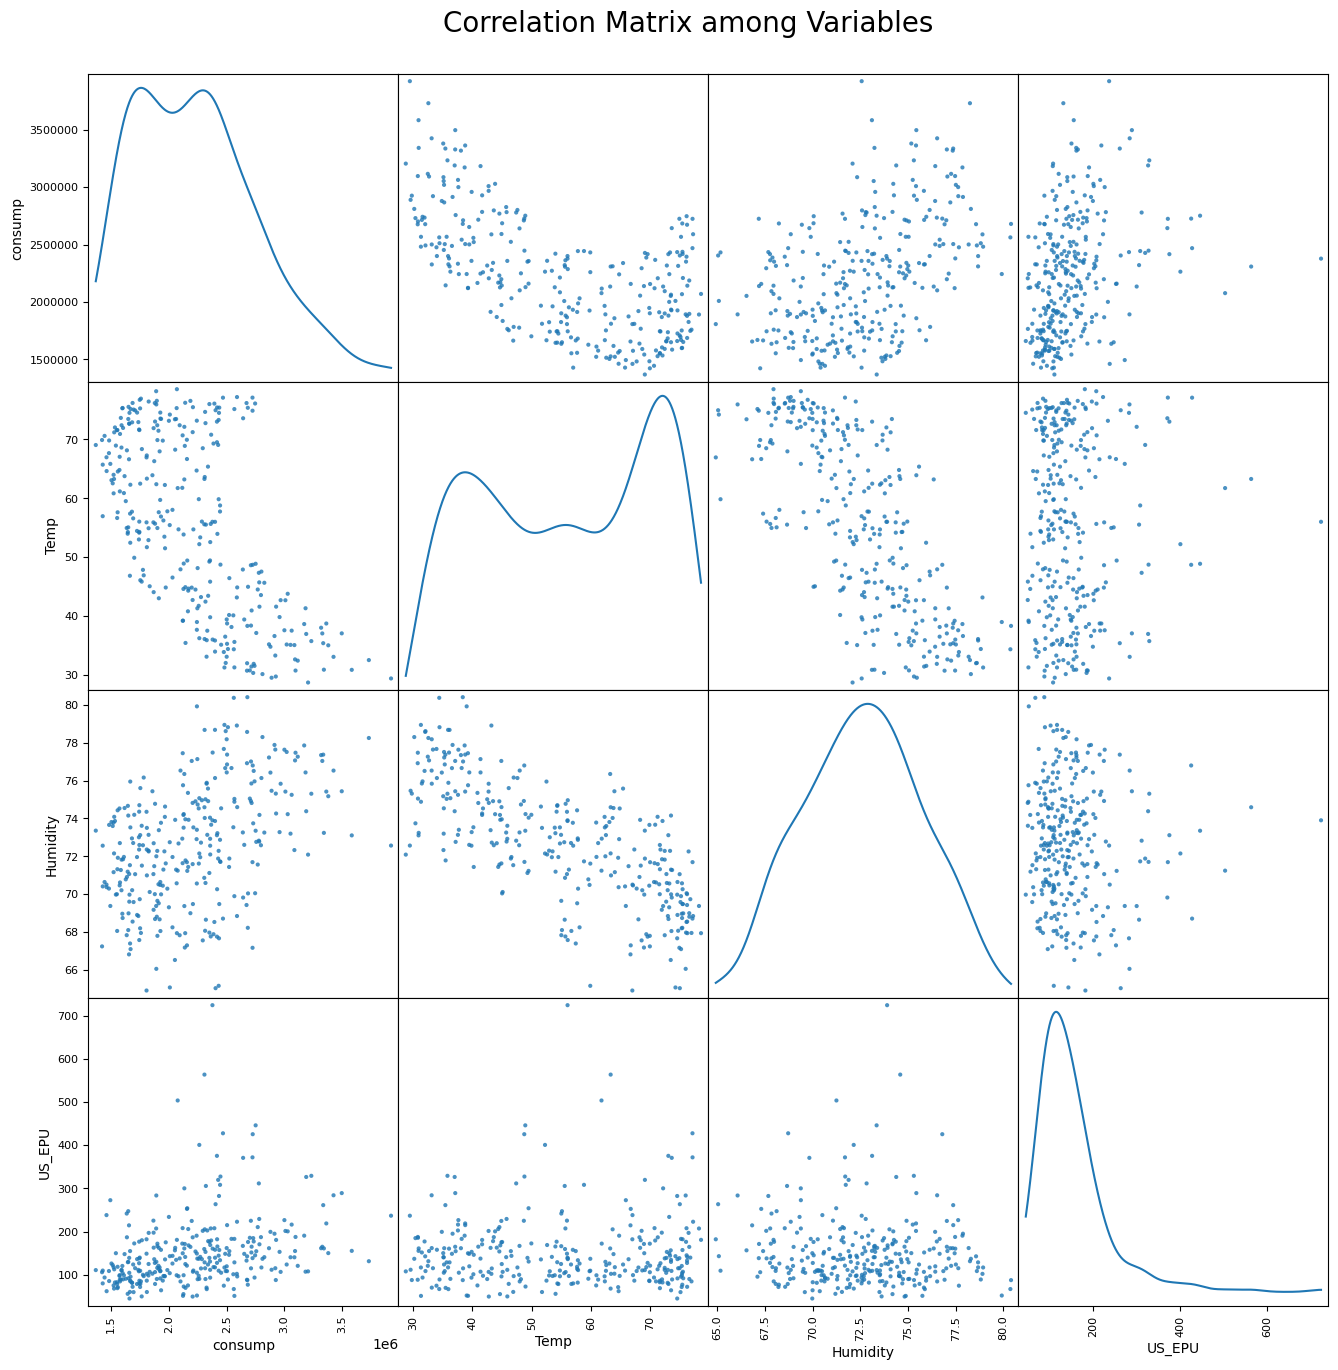

In [79]:
# =============================
# CORRELATION MATRIX STYLE PLOT
# =============================

from pandas.plotting import scatter_matrix

# Select columns that actually exist in your dataset
corr_features = [
    'consump',
    'Temp',
    'Humidity',
    'US_EPU'
]

# Keep only existing columns
corr_features = [
    col for col in corr_features
    if col in full_df.columns
]

# Create scatter matrix
scatter_matrix(
    full_df[corr_features],
    figsize=(16,16),
    diagonal='kde',
    alpha=0.8
)

plt.suptitle(
    'Correlation Matrix among Variables',
    fontsize=20,
    y=0.92
)

plt.show()

In [80]:
# =============================
# RESIDUAL VALUE COMPARISON TABLE
# =============================

residual_comparison_df = pd.DataFrame({
    'Date': y_test.index,
    
    'Actual': y_test.values,
    
'TimesFM_Predicted': timesfm_consumption[:len(y_test)],
'TimesFM_Residual': y_test.values - timesfm_consumption[:len(y_test)],
    
    'Hybrid_Predicted': hybrid_pred,
    'Hybrid_Residual': hybrid_residuals,
    
    'Ensemble_Predicted': ensemble_pred,
    'Ensemble_Residual': ensemble_residuals
})

residual_comparison_df

,Date,Actual,TimesFM_Predicted,TimesFM_Residual,Hybrid_Predicted,Hybrid_Residual,Ensemble_Predicted,Ensemble_Residual
0,2025-01-01,3921572,3574584.50,346987.50,3583198.25,338373.75,3590623.50,330948.50
1,2025-02-01,3232332,3212554.25,19777.75,3017920.00,214412.00,3057063.00,175269.00
2,2025-03-01,2750755,2959550.50,-208795.50,2757351.75,-6596.75,2830505.50,-79750.50
3,2025-04-01,2377114,2503676.50,-126562.50,2387559.00,-10445.00,2437839.50,-60725.50
4,2025-05-01,2308069,2354450.50,-46381.50,2374697.25,-66628.25,2365700.25,-57631.25
5,2025-06-01,2416004,2436325.25,-20321.25,2444615.75,-28611.75,2448304.50,-32300.50
6,2025-07-01,2723522,2671405.00,52117.00,2662563.50,60958.50,2705364.75,18157.25
7,2025-08-01,2642491,2650055.00,-7564.00,2699773.00,-57282.00,2664824.50,-22333.50
8,2025-09-01,2426692,2416394.50,10297.50,2437594.50,-10902.50,2451451.75,-24759.75
9,2025-10-01,2443155,2488797.25,-45642.25,2440204.75,2950.25,2449670.00,-6515.00
